In [1]:
from typing_extensions import TypedDict
from typing import List
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

llm = init_chat_model("openai:gpt-5-nano")

In [2]:
class State(TypedDict):

    dish: str
    ingredients: list[dict]
    recipe_steps: str
    plating_instructions: str


class Ingredient(BaseModel):

    name: str
    quantity: str
    unit: str


class IngredientsOutput(BaseModel):

    ingredients: List[Ingredient]

In [3]:
"""Prompt Chaining"""


def list_ingredients(state: State):
    structured_llm = llm.with_structured_output(IngredientsOutput)  # output form 강제
    response = structured_llm.invoke(
        f"{state['dish']}를 만드는 데 필요한 재료 5-8가지를 나열하세요."
    )
    return {"ingredients": response.ingredients}  # structured output


def create_recipe(state: State):
    response = llm.invoke(
        f"{state['ingredients']} 이 재료들을 사용하여, {state['dish']}를 위한 단계별 요리법을 작성하세요."
    )
    return {"recipe_steps": response.content}  # normal llm


def describe_plating(state: State):
    response = llm.invoke(
        f"{state['recipe_steps']}를 기반으로 {state['dish']}를 어떻게 아름답게 플레이팅할지 설명하세요."
    )
    return {"plating_instructions": response.content}  # normal llm


def gate(state: State):

    ingredients = state["ingredients"]

    if len(ingredients) > 8 or len(ingredients) < 3:
        return False

    return True

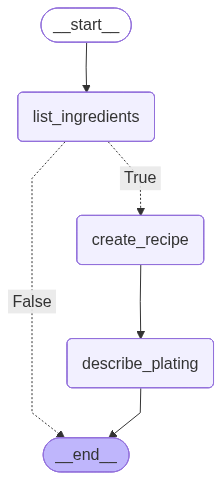

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("list_ingredients", list_ingredients)
graph_builder.add_node("create_recipe", create_recipe)
graph_builder.add_node("describe_plating", describe_plating)

graph_builder.add_edge(START, "list_ingredients")
graph_builder.add_conditional_edges(
    "list_ingredients",
    gate,
    {
        True: "create_recipe",
        # False: END,
        False: "list_ingredients",
    },
)
graph_builder.add_edge("create_recipe", "describe_plating")
graph_builder.add_edge("describe_plating", END)

graph = graph_builder.compile()

graph

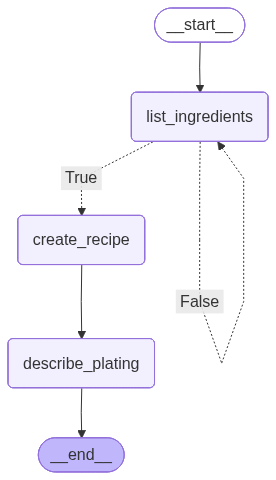

In [5]:
graph

In [5]:
# graph.invoke({"dish": "sandwich"})